In [1]:
import pandas as pd
import talib as ta
import numpy as np
from pathlib import Path

## テクニカルをここで構築

In [2]:
src_tr_dir = Path('../../data/main/expansion/technical/daily_technical')
dst_tr_csv = Path('./weekly_TR.csv')
wed_csv = Path('../../scripts/merge_series_tafa/weekly_separated.csv')

In [3]:
wed_data = pd.read_csv(wed_csv, usecols=['date'])
wed_data['date'] = wed_data['date'].astype(str).str.replace('/', '')

In [4]:
files = [pd.read_csv(f, usecols=['nikkei', 'open', 'high', 'low', 'close']) for f in src_tr_dir.rglob('.') if (f.suffix == '.csv') and (f.stem[25:33] in wed_data['date'].values)]
tr_csv = pd.concat(files, ignore_index=True)

In [5]:
tr_csv[tr_csv['nikkei'] == 'N0000001'].head(20)

,nikkei,open,high,low,close
0,N0000001,142.0,142.0,137.0,139.0
4608,N0000001,131.0,133.0,131.0,131.0
9216,N0000001,134.0,135.0,131.0,132.0
13824,N0000001,136.0,136.0,133.0,133.0
18432,N0000001,140.0,141.0,138.0,141.0
23040,N0000001,142.0,144.0,141.0,144.0
27648,N0000001,147.0,150.0,146.0,149.0
32256,N0000001,150.0,150.0,147.0,148.0
36864,N0000001,152.0,154.0,151.0,154.0
41472,N0000001,145.0,149.0,144.0,149.0


In [6]:
tr_csv['week_id'] = (tr_csv.index / 4608).astype(int)

In [7]:
tr_csv.rename({
    'high': 'weekly_high',
    'low': 'weekly_low'
}, axis=1, inplace=True)
new_order = ['nikkei', 'week_id', 'open', 'weekly_high', 'weekly_low', 'close']
tr_csv = tr_csv[new_order]

In [8]:
tr_csv = tr_csv.sort_values(by = ['nikkei', 'week_id'])

以下は計算部分である

In [9]:
def group_func(group: pd.DataFrame) -> pd.DataFrame:

    group = group.interpolate(method='pad', limit_area='inside', limit=5)
    group['return'] = np.nan
    group['10mom']  = np.nan
    group['slowk']  = np.nan
    group['slowd']  = np.nan
    group['5ma']    = np.nan
    group['15ma']   = np.nan
    group['40ma']   = np.nan
    group['rsi14']  = np.nan
    group['signal'] = np.nan
    group['macd']   = np.nan
    group['hist']   = np.nan
    group['bb1u']   = np.nan
    group['bb1l']   = np.nan
    group['bb2u']   = np.nan
    group['bb2l']   = np.nan

    group_tradable = group.loc[group.loc[:, 'open':'close'].notna().all(axis=1), :]
    
    group_tradable['return'] = group_tradable['close'].pct_change()

    group_tradable['10mom'] = group_tradable['close'] / group_tradable['close'].shift(10) - 1

    group_tradable['macd'], group_tradable['signal'], group_tradable['hist'] = ta.MACD(
        group_tradable['close'], fastperiod=12, slowperiod=26, signalperiod=9
    )

    group_tradable['slowk'], group_tradable['slowd'] = ta.STOCH(
        group_tradable['weekly_high'], group_tradable['weekly_low'], group_tradable['close'], 
        fastk_period=5, slowk_period=3, slowk_matype=0, slowd_period=3, slowd_matype=0
    )

    group_tradable['5ma']  = ta.SMA(group_tradable['close'], timeperiod=5)
    group_tradable['15ma'] = ta.SMA(group_tradable['close'], timeperiod=15)
    group_tradable['40ma'] = ta.SMA(group_tradable['close'], timeperiod=40)

    group_tradable['rsi14'] = ta.RSI(group_tradable['close'], timeperiod=14)

    group_tradable['bb1u'], _, group_tradable['bb1l'] = ta.BBANDS(
        group_tradable['close'], timeperiod=5, nbdevup=1, nbdevdn=1, matype=0
    )
    group_tradable['bb2u'], _, group_tradable['bb2l'] = ta.BBANDS(
        group_tradable['close'], timeperiod=5, nbdevup=2, nbdevdn=2, matype=0
    )

    group_tradable.loc[group_tradable.iloc[:, 2:6].isna().all(axis=1), 'open':'bb2l'] = np.nan
    group_tradable.iloc[:40, 2:] = np.nan

    group.loc[group_tradable.index, :] = group_tradable.loc[group_tradable.index, :]

    return group

In [10]:
grouped_df = (
    tr_csv
    .groupby('nikkei')
    .apply(group_func)
).reset_index(drop=True)

C:\Users\Ito Yuki\AppData\Local\Temp\ipykernel_26976\1949258487.py:3: FutureWarning: DataFrame.interpolate with method=pad is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  group = group.interpolate(method='pad', limit_area='inside', limit=5)
C:\Users\Ito Yuki\AppData\Local\Temp\ipykernel_26976\1949258487.py:3: FutureWarning: DataFrame.interpolate with method=pad is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  group = group.interpolate(method='pad', limit_area='inside', limit=5)
C:\Users\Ito Yuki\AppData\Local\Temp\ipykernel_26976\1949258487.py:3: FutureWarning: DataFrame.interpolate with method=pad is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  group = group.interpolate(method='pad', limit_area='inside', limit=5)
C:\Users\Ito Yuki\AppData\Local\Temp\ipykernel_26976\1949258487.py:3: FutureWarning: DataFrame.interpolate with method=pad is deprecated and will

In [11]:
grouped_df = grouped_df.sort_values(by = ['week_id', 'nikkei']).reset_index(drop=True)

In [12]:
grouped_df.to_csv(dst_tr_csv, index=False)

In [13]:
grouped_df

,nikkei,week_id,open,weekly_high,weekly_low,close,return,10mom,slowk,slowd,...,15ma,40ma,rsi14,signal,macd,hist,bb1u,bb1l,bb2u,bb2l
0,N0000001,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,N0000002,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,N0000003,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,N0000004,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,N0000005,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5524987,N0091164,1198,925.0,974.0,925.0,931.0,-0.044148,0.192061,78.264183,85.377201,...,804.266667,785.600,71.689412,14.130542,34.562736,20.432194,944.606709,819.393291,1007.213418,756.786582
5524988,N0091165,1198,1528.0,1535.0,1523.0,1527.0,0.001311,-0.060886,12.011317,19.967421,...,1588.733333,1611.375,36.960042,-13.402770,-21.447777,-8.045007,1577.374563,1530.225437,1600.949125,1506.650875
5524989,N0091290,1198,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5524990,N0091517,1198,3715.0,3720.0,3615.0,3625.0,-0.026846,0.115385,58.968736,74.650914,...,3275.266667,2955.550,66.944792,206.363270,255.194515,48.831245,3779.785385,3640.214615,3849.570771,3570.429229



## ファンダをここで構築

### セットアップ

In [14]:
src_fr_dir = Path('../../data/main/master/product/weekly_remodify_fundamental')
dst_fr_csv = Path('weekly_FR.csv')

In [15]:
src_stc_csv = pd.read_csv('../../data/main/master/product/.keep/weekly_stcinfo.csv')

In [16]:
remain_cols = [
    'nikkei',
    '営業費用',
    '法人税等調整額／繰延税金費用',
    'その他営業外費用',
    'その他営業外収益',
    '営業利益',
    'その他流動資産／その他の金融資産',
    'その他流動負債／その他の金融負債',
    '有形固定資産の売却による収入',
    '営業外費用',
    '非支配株主に帰属する当期純利益',
    '固定資産の売却による収入',
    'その他特別利益',
    'その他無形固定資産／その他無形資産',
    '投資有価証券の取得による支出（▲）',
    '投資その他の資産の売却による収入',
    'その他の流動資産の減少額（▲増）',
    'その他の小計欄より上の営業キャッシュフロー',
    '無形固定資産の売却による収入',

    # ファンダメンタルズを計算するための基礎データ
    '流動資産',
    '固定資産／非流動資産',
    '資産合計',
    '流動負債',
    '負債合計',
    '長期借入金',
    '資本金',
    '資本剰余金',
    '利益剰余金',
    '自己資本／親会社の所有者に帰属する資本',
    '売上総利益',
    '売上高・営業収益',
    '経常利益／税金等調整前当期純利益',
    '減価償却費',
    '法人税等',
    '営業活動によるキャッシュフロー',
    '投資活動によるキャッシュフロー',
    '現金及び現金同等物の期首残高',
    '現金及び現金同等物の期末残高',
    '現金及び預金',
    '株主資本',
    '税金等調整前当期純利益',
    '特別利益',
    '特別損失',
    '当期純利益（連結）',
    '短期借入金・社債合計',
    '１年内返済の借入金',
    '社債・転換社債',
    '現金及び現金同等物の増加額（▲減）',

]

In [17]:
files = [pd.read_csv(f, usecols=remain_cols) for f in src_fr_dir.rglob('.') if f.suffix == '.csv']
fr_csv = pd.concat(files, ignore_index=True)

In [18]:
tr_csv = pd.read_csv('weekly_TR.csv')

In [19]:
tr_csv

,nikkei,week_id,open,weekly_high,weekly_low,close,return,10mom,slowk,slowd,...,15ma,40ma,rsi14,signal,macd,hist,bb1u,bb1l,bb2u,bb2l
0,N0000001,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,N0000002,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,N0000003,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,N0000004,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,N0000005,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5524987,N0091164,1198,925.0,974.0,925.0,931.0,-0.044148,0.192061,78.264183,85.377201,...,804.266667,785.600,71.689412,14.130542,34.562736,20.432194,944.606709,819.393291,1007.213418,756.786582
5524988,N0091165,1198,1528.0,1535.0,1523.0,1527.0,0.001311,-0.060886,12.011317,19.967421,...,1588.733333,1611.375,36.960042,-13.402770,-21.447777,-8.045007,1577.374563,1530.225437,1600.949125,1506.650875
5524989,N0091290,1198,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5524990,N0091517,1198,3715.0,3720.0,3615.0,3625.0,-0.026846,0.115385,58.968736,74.650914,...,3275.266667,2955.550,66.944792,206.363270,255.194515,48.831245,3779.785385,3640.214615,3849.570771,3570.429229


In [20]:
fr_csv['week_id'] = (fr_csv.index / 4608).astype(int)

In [21]:
new_fr_order = ['nikkei', 'week_id'] + [col for col in remain_cols if col not in  ['nikkei', 'week_id']]

In [22]:
fr_csv = fr_csv[new_fr_order]

In [23]:
fr_csv.sort_values(by = ['week_id', 'nikkei'], inplace=True)

In [24]:
fr_csv

,nikkei,week_id,営業費用,法人税等調整額／繰延税金費用,その他営業外費用,その他営業外収益,営業利益,その他流動資産／その他の金融資産,その他流動負債／その他の金融負債,有形固定資産の売却による収入,...,現金及び預金,株主資本,税金等調整前当期純利益,特別利益,特別損失,当期純利益（連結）,短期借入金・社債合計,１年内返済の借入金,社債・転換社債,現金及び現金同等物の増加額（▲減）
0,N0000001,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,N0000002,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,N0000003,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,N0000004,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,N0000005,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5524987,N0091164,1198,2312.0,25.0,4.0,3.0,-121.0,189.0,136.0,0.0,...,7110.0,14109.0,185.0,447.0,0.0,265.0,100.0,200.0,NaN,831.0
5524988,N0091165,1198,1823.0,-30.0,0.0,3.0,958.0,50.0,424.0,0.0,...,3766.0,7692.0,963.0,0.0,0.0,NaN,NaN,NaN,NaN,105.0
5524989,N0091290,1198,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5524990,N0091517,1198,50493.0,-444.0,27.0,118.0,4806.0,1577.0,1518.0,0.0,...,21649.0,57126.0,3254.0,0.0,1631.0,2498.0,2344.0,2344.0,NaN,5328.0


### ファンダを計算する

#### データの読み込み・確認等

In [25]:
fa_csv = pd.read_csv('../../data/main/master/product/.keep/weekly_stcinfo_V2.csv')

In [26]:
fa_csv.rename(
    columns={
        '期中平均株式数［累計］': '期中平均株式数累計',
        '１株当たり配当金（各期末）': '１株当たり配当金'
    }, inplace=True
)

In [27]:
fa_csv

,nikkei,week_id,期中平均株式数累計,１株当たり配当金
0,N0000001,0,NaN,NaN
1,N0000002,0,NaN,NaN
2,N0000003,0,NaN,NaN
3,N0000004,0,NaN,NaN
4,N0000005,0,NaN,NaN
...,...,...,...,...
5524987,N0091164,1198,70675864.0,7.0
5524988,N0091165,1198,25673462.0,0.0
5524989,N0091290,1198,NaN,NaN
5524990,N0091517,1198,45432240.0,35.0


In [28]:
fa_csv.count()

nikkei       5524992
week_id      5524992
期中平均株式数累計    1556151
１株当たり配当金     1560470
dtype: int64

In [29]:
src_stc_csv.count()

nikkei           5524992
week_id          5524992
期中平均株式数［累計］      1556151
１株当たり配当金（各期末）    1560470
dtype: int64

In [30]:
def impute_fa(group: pd.DataFrame) -> pd.DataFrame:
    group = group.interpolate(method='linear', limit_area='inside')
    group = group.ffill()
    group = group.fillna(group.mean())
    return group


g_fa_csv = (
    fa_csv
    .groupby('nikkei')
    .apply(impute_fa)
    .reset_index(drop=True)
)

C:\Users\Ito Yuki\AppData\Local\Temp\ipykernel_26976\1342724028.py:2: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  group = group.interpolate(method='linear', limit_area='inside')


In [31]:
fa_csv

,nikkei,week_id,期中平均株式数累計,１株当たり配当金
0,N0000001,0,NaN,NaN
1,N0000002,0,NaN,NaN
2,N0000003,0,NaN,NaN
3,N0000004,0,NaN,NaN
4,N0000005,0,NaN,NaN
...,...,...,...,...
5524987,N0091164,1198,70675864.0,7.0
5524988,N0091165,1198,25673462.0,0.0
5524989,N0091290,1198,NaN,NaN
5524990,N0091517,1198,45432240.0,35.0


In [32]:
big_csv = pd.concat([tr_csv, fa_csv.iloc[:, 2:], fr_csv.iloc[:, 2:]], axis=1)

インデックスが合致していたか念のため確認

In [33]:
(tr_csv.iloc[:, :2] == fa_csv.iloc[:, :2]).nunique()

nikkei     1
week_id    1
dtype: int64

In [34]:
(fa_csv.iloc[:, :2] == fr_csv.iloc[:, :2]).nunique()

nikkei     1
week_id    1
dtype: int64

In [35]:
(tr_csv.iloc[:, :2] == fr_csv.iloc[:, :2]).nunique()

nikkei     1
week_id    1
dtype: int64

確認が終了したため以下から処理に移る

In [36]:
big_csv['上場フラグ'] = 0
mask = big_csv.loc[:, 'open':'close'].notna().any(axis=1)
big_csv.loc[mask, '上場フラグ'] = 1

In [37]:
fa_csv.count()

nikkei       5524992
week_id      5524992
期中平均株式数累計    1556151
１株当たり配当金     1560470
dtype: int64

#### ファンダの計算が続く

In [38]:
big_csv.loc[big_csv['株主資本'].isna() & big_csv['上場フラグ'] == 1, '株主資本'] = (
    big_csv['資本金'].fillna(0) +
    big_csv['資本剰余金'].fillna(0) +
    big_csv['利益剰余金'].fillna(0)
)

big_csv.loc[big_csv['株主資本'] == 0, '株主資本'] = np.nan
big_csv.drop(columns=['資本金', '資本剰余金', '利益剰余金'], inplace=True)
print(f'Exit Ratio : {big_csv.loc[big_csv['上場フラグ'] == 1, '株主資本'].notnull().sum() / len(big_csv.loc[big_csv['上場フラグ'] == 1, '株主資本'])}')

Exit Ratio : 0.8390736036062167


In [39]:
big_csv.loc[big_csv['税金等調整前当期純利益'].isna() & big_csv['上場フラグ'] == 1, '税金等調整前当期純利益'] = (
    big_csv['経常利益／税金等調整前当期純利益'].fillna(0) +
    big_csv['特別利益'].fillna(0) -
    big_csv['特別損失'].fillna(0)
)

big_csv.loc[big_csv['税金等調整前当期純利益'] == 0, '税金等調整前当期純利益'] = np.nan
print(f'Exit Ratio : {big_csv.loc[big_csv['上場フラグ'] == 1, '税金等調整前当期純利益'].notnull().sum() / len(big_csv.loc[big_csv['上場フラグ'] == 1, '税金等調整前当期純利益'])}')

Exit Ratio : 0.8153926213830769


In [40]:
big_csv['当期純利益'] = big_csv['当期純利益（連結）']
big_csv.drop(columns=['当期純利益（連結）'], inplace=True)
big_csv.loc[big_csv['当期純利益'].isna() & big_csv['上場フラグ'] == 1, '当期純利益'] = (
    big_csv['税金等調整前当期純利益'] -
    big_csv['法人税等'].fillna(0)
)

big_csv.loc[big_csv['当期純利益'] == 0, '当期純利益'] = np.nan
print(f'Exit Ratio : {big_csv.loc[big_csv['上場フラグ'] == 1, '当期純利益'].notnull().sum() / len(big_csv.loc[big_csv['上場フラグ'] == 1, '当期純利益'])}')

Exit Ratio : 0.8120877189689797


In [41]:
big_csv['フリーキャッシュフロー'] = (
    big_csv['営業活動によるキャッシュフロー'].fillna(0) +
    big_csv['投資活動によるキャッシュフロー'].fillna(0)
)
big_csv.loc[big_csv['フリーキャッシュフロー'] == 0, 'フリーキャッシュフロー'] = np.nan
print(f'Exit Ratio : {big_csv.loc[big_csv['上場フラグ'] == 1, 'フリーキャッシュフロー'].notnull().sum() / len(big_csv.loc[big_csv['上場フラグ'] == 1, 'フリーキャッシュフロー'])}')

Exit Ratio : 0.8115512908228815


In [42]:
big_csv['ギアリング比率'] = (
    big_csv['負債合計'] / 
    big_csv['自己資本／親会社の所有者に帰属する資本']
)
big_csv.loc[big_csv['ギアリング比率'] == 0, 'ギアリング比率'] = np.nan
print(f'Exit Ratio : {big_csv.loc[big_csv['上場フラグ'] == 1, 'ギアリング比率'].notnull().sum() / len(big_csv.loc[big_csv['上場フラグ'] == 1, 'ギアリング比率'])}')

Exit Ratio : 0.8392588965345446


In [43]:
big_csv['総資産回転率'] = (
    big_csv['売上高・営業収益'] /
    big_csv['資産合計']
)
big_csv.loc[big_csv['総資産回転率'] == 0, '総資産回転率'] = np.nan
print(f'Exit Ratio : {big_csv.loc[big_csv['上場フラグ'] == 1, '総資産回転率'].notnull().sum() / len(big_csv.loc[big_csv['上場フラグ'] == 1, '総資産回転率'])}')

Exit Ratio : 0.8270677820641222


In [44]:
big_csv['固定比率'] = (
    big_csv['固定資産／非流動資産'] /
    big_csv['資産合計']
)

big_csv.loc[big_csv['固定比率'] == 0, '固定比率'] = np.nan
print(f'Exit Ratio : {big_csv.loc[big_csv['上場フラグ'] == 1, '固定比率'].notnull().sum() / len(big_csv.loc[big_csv['上場フラグ'] == 1, '固定比率'])}')

Exit Ratio : 0.8390381147212331


In [45]:
big_csv['流動比率'] = (
    big_csv['流動資産'] /
    big_csv['流動負債']
)
big_csv.loc[big_csv['流動比率'] == 0, '流動比率'] = np.nan
print(f'Exit Ratio : {big_csv.loc[big_csv['上場フラグ'] == 1, '流動比率'].notnull().sum() / len(big_csv.loc[big_csv['上場フラグ'] == 1, '流動比率'])}')

Exit Ratio : 0.8390483518995937


In [46]:
big_csv['自己資本比率'] = (
    big_csv['自己資本／親会社の所有者に帰属する資本'] /
    big_csv['資産合計']
)
big_csv.loc[big_csv['自己資本比率'] == 0, '自己資本比率'] = np.nan
print(f'Exit Ratio : {big_csv.loc[big_csv['上場フラグ'] == 1, '自己資本比率'].notnull().sum() / len(big_csv.loc[big_csv['上場フラグ'] == 1, '自己資本比率'])}')

Exit Ratio : 0.8394168903205772


In [47]:
big_csv['売上高総利益率'] = (
    big_csv['売上総利益'] /
    big_csv['売上高・営業収益']
)

big_csv.loc[big_csv['売上高総利益率'] == 0, '売上高総利益率'] = np.nan
print(f'Exit Ratio : {big_csv.loc[big_csv['上場フラグ'] == 1, '売上高総利益率'].notnull().sum() / len(big_csv.loc[big_csv['上場フラグ'] == 1, '売上高総利益率'])}')

Exit Ratio : 0.8193039059954035


In [48]:
big_csv['売上高営業利益率'] = (
    big_csv['売上総利益'] /
    big_csv['売上高・営業収益']
)

big_csv.loc[big_csv['売上高営業利益率'] == 0, '売上高営業利益率'] = np.nan
print(f'Exit Ratio : {big_csv.loc[big_csv['上場フラグ'] == 1, '売上高営業利益率'].notnull().sum() / len(big_csv.loc[big_csv['上場フラグ'] == 1, '売上高営業利益率'])}')

Exit Ratio : 0.8193039059954035


In [49]:
big_csv['売上高経常利益率'] = (
    big_csv['売上総利益'] /
    big_csv['経常利益／税金等調整前当期純利益']
)

big_csv.loc[big_csv['売上高経常利益率'] == 0, '売上高経常利益率'] = np.nan
print(f'Exit Ratio : {big_csv.loc[big_csv['上場フラグ'] == 1, '売上高経常利益率'].notnull().sum() / len(big_csv.loc[big_csv['上場フラグ'] == 1, '売上高経常利益率'])}')

Exit Ratio : 0.8193039059954035


In [50]:
big_csv['有利子負債'] = (
    big_csv['短期借入金・社債合計'].fillna(0) +
    big_csv['１年内返済の借入金'].fillna(0) +
    big_csv['社債・転換社債'].fillna(0) +
    big_csv['長期借入金'].fillna(0)
)

big_csv.loc[big_csv['売上高経常利益率'] == 0, '売上高経常利益率'] = np.nan
print(f'Exit Ratio : {big_csv.loc[big_csv['上場フラグ'] == 1, '売上高経常利益率'].notnull().sum() / len(big_csv.loc[big_csv['上場フラグ'] == 1, '売上高経常利益率'])}')

Exit Ratio : 0.8193039059954035


In [51]:
# big_csv['流動資産率'] = (
#     big_csv['流動資産'] /
#     big_csv['資産合計']
# )

# big_csv.loc[big_csv['流動資産率'] == 0, '流動資産率'] = np.nan
# print(f'Exit Ratio : {big_csv.loc[big_csv['上場フラグ'] == 1, '流動資産率'].notnull().sum() / len(big_csv.loc[big_csv['上場フラグ'] == 1, '流動資産率'])}')

In [52]:
# big_csv['固定資産率'] = (
#     big_csv['固定資産／非流動資産'] /
#     big_csv['資産合計']
# )

# big_csv.loc[big_csv['固定資産率'] == 0, '固定資産率'] = np.nan
# print(f'Exit Ratio : {big_csv.loc[big_csv['上場フラグ'] == 1, '固定資産率'].notnull().sum() / len(big_csv.loc[big_csv['上場フラグ'] == 1, '固定資産率'])}')

In [53]:
big_csv.loc[big_csv['現金及び現金同等物の増加額（▲減）'].isna() & big_csv['上場フラグ'] == 1, '現金及び現金同等物の増加額（▲減）'] = (
    big_csv['現金及び現金同等物の期末残高'].fillna(0) -
    big_csv['現金及び現金同等物の期首残高'].fillna(0)
)

big_csv.loc[big_csv['現金及び現金同等物の増加額（▲減）'] == 0, '現金及び現金同等物の増加額（▲減）'] = np.nan
print(f'Exit Ratio : {big_csv.loc[big_csv['上場フラグ'] == 1, '現金及び現金同等物の増加額（▲減）'].notnull().sum() / len(big_csv.loc[big_csv['上場フラグ'] == 1, '現金及び現金同等物の増加額（▲減）'])}')

Exit Ratio : 0.8118338369456355


In [54]:
big_csv['EBITDA'] = (
    big_csv['営業利益'].fillna(0) +
    big_csv['減価償却費'].fillna(0)
)
big_csv.loc[big_csv['EBITDA'] == 0, 'EBITDA'] = np.nan
print(f'Exit Ratio : {big_csv.loc[big_csv['上場フラグ'] == 1, 'EBITDA'].notnull().sum() / len(big_csv.loc[big_csv['上場フラグ'] == 1, 'EBITDA'])}')

Exit Ratio : 0.8273056258413681


In [55]:
big_csv['ROE'] = (
    big_csv['当期純利益'] /
    big_csv['自己資本／親会社の所有者に帰属する資本']
)

big_csv.loc[big_csv['ROE'] == 0, 'ROE'] = np.nan
print(f'Exit Ratio : {big_csv.loc[big_csv['上場フラグ'] == 1, 'ROE'].notnull().sum() / len(big_csv.loc[big_csv['上場フラグ'] == 1, 'ROE'])}')

Exit Ratio : 0.8120733869192748


In [56]:
big_csv['ROA'] = (
    big_csv['当期純利益'] /
    big_csv['資産合計']
)

big_csv.loc[big_csv['ROA'] == 0, 'ROA'] = np.nan
print(f'Exit Ratio : {big_csv.loc[big_csv['上場フラグ'] == 1, 'ROA'].notnull().sum() / len(big_csv.loc[big_csv['上場フラグ'] == 1, 'ROA'])}')

Exit Ratio : 0.8120733869192748


In [57]:
big_csv['株主資本回転率'] = (
    big_csv['売上高・営業収益'] /
    big_csv['株主資本']
)

big_csv.loc[big_csv['株主資本回転率'] == 0, '株主資本回転率'] = np.nan
print(f'Exit Ratio : {big_csv.loc[big_csv['上場フラグ'] == 1, '株主資本回転率'].notnull().sum() / len(big_csv.loc[big_csv['上場フラグ'] == 1, '株主資本回転率'])}')

Exit Ratio : 0.8268142412800568


In [58]:
big_csv['PER'] = (
    (big_csv['close'] * big_csv['期中平均株式数累計']) /
    (big_csv['当期純利益'] * 1e06)
)

In [59]:
big_csv['PBR'] = (
    (big_csv['close'] * big_csv['期中平均株式数累計']) /
    (big_csv['株主資本'] * 1e06)
)

In [60]:
big_csv['EV'] = (
    (big_csv['close'] * big_csv['期中平均株式数累計']) + (big_csv['有利子負債'] * 1e06 - big_csv['現金及び預金'] * 1e06)
)

In [61]:
big_csv['EPS'] = (
    big_csv['当期純利益'] * 1e06 /
    big_csv['期中平均株式数累計']
)

In [62]:
big_csv['BPS'] = (
    big_csv['株主資本'] * 1e06 /
    big_csv['期中平均株式数累計']
)

In [63]:
big_csv['CFPS'] = (
    (big_csv['当期純利益'] * 1e06 + big_csv['減価償却費'] * 1e06) /
    big_csv['期中平均株式数累計']
)

In [64]:
big_csv['PCFR'] = (
    big_csv['close'] / big_csv['CFPS']
)

In [65]:
def group_function(df:pd.DataFrame, nikkei:str, cols2:str) -> pd.DataFrame:
    for col in cols2:
        print('\r', f'Processing nikkei: {nikkei}, column: {col}', end='               ')
        df[f'{col}の増加額'] = (
            df[col] - df[col].shift(1)
        )

        df.loc[df[f'{col}の増加額'] == 0, f'{col}の増加額'] = np.nan
        # print(f'Exit Ratio : {df.loc[df['上場フラグ'] == 1, f'{col}の増加額'].notnull().sum() / len(df.loc[df['上場フラグ'] == 1, f'{col}の増加額'])}')

In [66]:
complete_big_csv = (
    big_csv
    .groupby('nikkei')
    .apply
    (
        lambda group: group_function(df=group, nikkei=group.name, cols2=['売上総利益', '営業利益', '経常利益／税金等調整前当期純利益', '売上高・営業収益'])
    )
    .reset_index(drop=True))

 Processing nikkei: N0091607, column: 売上高・営業収益                       

C:\Users\Ito Yuki\AppData\Local\Temp\ipykernel_26976\1590365498.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply


In [67]:
big_csv_alpha = big_csv.drop(
    columns=[
        '流動資産',
        '固定資産／非流動資産',
        '資産合計',
        '流動負債',
        '負債合計',
        '長期借入金',
        # '資本金',
        # '資本剰余金',
        # '利益剰余金',
        '自己資本／親会社の所有者に帰属する資本',
        '売上総利益',
        '売上高・営業収益',
        '経常利益／税金等調整前当期純利益',
        '減価償却費',
        '法人税等',
        '営業活動によるキャッシュフロー',
        '投資活動によるキャッシュフロー',
        '現金及び現金同等物の期首残高',
        '現金及び現金同等物の期末残高',
        '現金及び預金',
        '株主資本',
        '税金等調整前当期純利益',
        '特別利益',
        '特別損失',
        # '当期純利益（連結）',
        '短期借入金・社債合計',
        '１年内返済の借入金',
        '社債・転換社債',
        '現金及び現金同等物の増加額（▲減）'
    ]
)

In [68]:
big_csv_alpha

,nikkei,week_id,open,weekly_high,weekly_low,close,return,10mom,slowk,slowd,...,ROE,ROA,株主資本回転率,PER,PBR,EV,EPS,BPS,CFPS,PCFR
0,N0000001,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,N0000002,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,N0000003,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,N0000004,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,N0000005,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5524987,N0091164,1198,925.0,974.0,925.0,931.0,-0.044148,0.192061,78.264183,85.377201,...,0.016540,0.014093,0.155220,248.298979,4.663635,5.968923e+10,3.749512,199.629678,17.177010,54.200354
5524988,N0091165,1198,1528.0,1535.0,1523.0,1527.0,0.001311,-0.060886,12.011317,19.967421,...,0.087092,0.066337,0.361544,58.512502,5.096643,3.543738e+10,26.096987,299.608989,31.998022,47.721700
5524989,N0091290,1198,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5524990,N0091517,1198,3715.0,3720.0,3615.0,3625.0,-0.026846,0.115385,58.968736,74.650914,...,0.043559,0.025002,0.968018,65.929492,2.882958,1.477309e+11,54.982981,1257.389026,176.515620,20.536426


In [69]:
alpha_order = ['nikkei', 'week_id', '上場フラグ'] + [col for col in big_csv_alpha.columns if col not in ['nikkei', 'week_id', '上場フラグ']]

#### アルファ版が完成する

In [70]:
big_csv_alpha

,nikkei,week_id,open,weekly_high,weekly_low,close,return,10mom,slowk,slowd,...,ROE,ROA,株主資本回転率,PER,PBR,EV,EPS,BPS,CFPS,PCFR
0,N0000001,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,N0000002,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,N0000003,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,N0000004,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,N0000005,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5524987,N0091164,1198,925.0,974.0,925.0,931.0,-0.044148,0.192061,78.264183,85.377201,...,0.016540,0.014093,0.155220,248.298979,4.663635,5.968923e+10,3.749512,199.629678,17.177010,54.200354
5524988,N0091165,1198,1528.0,1535.0,1523.0,1527.0,0.001311,-0.060886,12.011317,19.967421,...,0.087092,0.066337,0.361544,58.512502,5.096643,3.543738e+10,26.096987,299.608989,31.998022,47.721700
5524989,N0091290,1198,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5524990,N0091517,1198,3715.0,3720.0,3615.0,3625.0,-0.026846,0.115385,58.968736,74.650914,...,0.043559,0.025002,0.968018,65.929492,2.882958,1.477309e+11,54.982981,1257.389026,176.515620,20.536426


In [71]:
big_csv_alpha = big_csv_alpha[alpha_order]

In [72]:
len(set(alpha_order))

64

In [73]:
big_csv_alpha

,nikkei,week_id,上場フラグ,open,weekly_high,weekly_low,close,return,10mom,slowk,...,ROE,ROA,株主資本回転率,PER,PBR,EV,EPS,BPS,CFPS,PCFR
0,N0000001,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,N0000002,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,N0000003,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,N0000004,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,N0000005,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5524987,N0091164,1198,1,925.0,974.0,925.0,931.0,-0.044148,0.192061,78.264183,...,0.016540,0.014093,0.155220,248.298979,4.663635,5.968923e+10,3.749512,199.629678,17.177010,54.200354
5524988,N0091165,1198,1,1528.0,1535.0,1523.0,1527.0,0.001311,-0.060886,12.011317,...,0.087092,0.066337,0.361544,58.512502,5.096643,3.543738e+10,26.096987,299.608989,31.998022,47.721700
5524989,N0091290,1198,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5524990,N0091517,1198,1,3715.0,3720.0,3615.0,3625.0,-0.026846,0.115385,58.968736,...,0.043559,0.025002,0.968018,65.929492,2.882958,1.477309e+11,54.982981,1257.389026,176.515620,20.536426


In [74]:
def group_interpolate(group: pd.DataFrame) -> pd.DataFrame:
    group[group['上場フラグ'] == 1] = group[group['上場フラグ'] == 1].interpolate(method='linear', limit_area='inside')
    group[group['上場フラグ'] == 1] = group[group['上場フラグ'] == 1].ffill()
    group[group['上場フラグ'] == 1] = group[group['上場フラグ'] == 1].fillna(group[group['上場フラグ'] == 1].mean())
    group.loc[group['上場フラグ'] == 0, 'open':] = np.nan
    return group

In [75]:
_ = (
    big_csv_alpha
    .groupby('nikkei')
    .apply(group_interpolate)
    .reset_index(drop=True)
)

C:\Users\Ito Yuki\AppData\Local\Temp\ipykernel_26976\3722949392.py:2: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  group[group['上場フラグ'] == 1] = group[group['上場フラグ'] == 1].interpolate(method='linear', limit_area='inside')
c:\Users\Ito Yuki\FINAL_PAPER\research_using_uv\.venv\Lib\site-packages\numpy\_core\_methods.py:51: RuntimeWarning: invalid value encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)
c:\Users\Ito Yuki\FINAL_PAPER\research_using_uv\.venv\Lib\site-packages\numpy\_core\_methods.py:51: RuntimeWarning: invalid value encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)
c:\Users\Ito Yuki\FINAL_PAPER\research_using_uv\.venv\Lib\site-packages\numpy\_core\_methods.py:51: RuntimeWarning: invalid value encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)
c:\U

In [76]:
len(big_csv_alpha[big_csv_alpha['上場フラグ'] == 1])

2930495

In [77]:
def group_funk_fillna_mean_market(group: pd.DataFrame) -> pd.DataFrame:
    group = group.replace([np.inf, -np.inf], np.nan)
    market_mean = group.loc[group['上場フラグ'] == 1, 'open':].mean()
    group.loc[group['上場フラグ'] == 1, 'open':] = group.loc[group['上場フラグ'] == 1, 'open':].fillna(market_mean)
    group = group.replace([np.inf, -np.inf], np.nan)
    group.loc[group['上場フラグ'] == 0, 'open':] = np.nan
    return group

In [78]:
big_csv_beta = (
    big_csv_alpha
    .groupby('week_id')
    .apply(group_funk_fillna_mean_market)
    .reset_index(drop=True)
)

C:\Users\Ito Yuki\AppData\Local\Temp\ipykernel_26976\3913622329.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(group_funk_fillna_mean_market)


In [79]:
big_csv_beta

,nikkei,week_id,上場フラグ,open,weekly_high,weekly_low,close,return,10mom,slowk,...,ROE,ROA,株主資本回転率,PER,PBR,EV,EPS,BPS,CFPS,PCFR
0,N0000001,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,N0000002,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,N0000003,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,N0000004,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,N0000005,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5524987,N0091164,1198,1,925.0,974.0,925.0,931.0,-0.044148,0.192061,78.264183,...,0.016540,0.014093,0.155220,248.298979,4.663635,5.968923e+10,3.749512,199.629678,17.177010,54.200354
5524988,N0091165,1198,1,1528.0,1535.0,1523.0,1527.0,0.001311,-0.060886,12.011317,...,0.087092,0.066337,0.361544,58.512502,5.096643,3.543738e+10,26.096987,299.608989,31.998022,47.721700
5524989,N0091290,1198,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5524990,N0091517,1198,1,3715.0,3720.0,3615.0,3625.0,-0.026846,0.115385,58.968736,...,0.043559,0.025002,0.968018,65.929492,2.882958,1.477309e+11,54.982981,1257.389026,176.515620,20.536426


In [80]:
state = big_csv_beta.count().reset_index()
state.columns = ['column_name', 'count']
state['non_exit_ratio'] = 1 - state['count'] / len(big_csv_beta[big_csv_beta['上場フラグ'] == 1])
state.sort_values(by='non_exit_ratio', ascending=False)

,column_name,count,non_exit_ratio
3,open,2930495,0.000000
6,close,2930495,0.000000
5,weekly_low,2930495,0.000000
4,weekly_high,2930495,0.000000
7,return,2930495,0.000000
...,...,...,...
59,EV,2930495,0.000000
63,PCFR,2930495,0.000000
2,上場フラグ,5524992,-0.885344
0,nikkei,5524992,-0.885344


In [81]:
big_csv_beta.to_csv('weekly_All_beta.csv')

#### 異常値の補完

In [82]:
from sklearn.svm import OneClassSVM
import matplotlib.pyplot as plt

In [83]:
big_csv_beta = pd.read_csv('weekly_All_beta.csv')

In [84]:
beta_volatility_df = pd.read_csv('weekly_beta_volatility.csv')

In [85]:
big_csv_beta

,Unnamed: 0,nikkei,week_id,上場フラグ,open,weekly_high,weekly_low,close,return,10mom,...,ROE,ROA,株主資本回転率,PER,PBR,EV,EPS,BPS,CFPS,PCFR
0,0,N0000001,0,0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,N0000002,0,0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,N0000003,0,0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,N0000004,0,0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,N0000005,0,0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5524987,5524987,N0091164,1198,1,925.0,974.0,925.0,931.0,-0.044148,0.192061,...,0.016540,0.014093,0.155220,248.298979,4.663635,5.968923e+10,3.749512,199.629678,17.177010,54.200354
5524988,5524988,N0091165,1198,1,1528.0,1535.0,1523.0,1527.0,0.001311,-0.060886,...,0.087092,0.066337,0.361544,58.512502,5.096643,3.543738e+10,26.096987,299.608989,31.998022,47.721700
5524989,5524989,N0091290,1198,0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5524990,5524990,N0091517,1198,1,3715.0,3720.0,3615.0,3625.0,-0.026846,0.115385,...,0.043559,0.025002,0.968018,65.929492,2.882958,1.477309e+11,54.982981,1257.389026,176.515620,20.536426


In [86]:
beta_volatility_df = beta_volatility_df.sort_values(by=['week_id', 'nikkei']).reset_index(drop=True)

In [87]:
beta_volatility_df

,nikkei,week_id,beta,volatility
0,N0000001,0,NaN,NaN
1,N0000002,0,NaN,NaN
2,N0000003,0,NaN,NaN
3,N0000004,0,NaN,NaN
4,N0000005,0,NaN,NaN
...,...,...,...,...
5524987,N0091164,1198,0.021839,0.037482
5524988,N0091165,1198,0.214372,0.013600
5524989,N0091290,1198,0.000000,0.000000
5524990,N0091517,1198,-0.211501,0.046426


In [88]:
big_csv_beta = pd.concat([big_csv_beta, beta_volatility_df.iloc[:, 2:]], axis=1)

In [89]:
def detect_anomalies(group: pd.DataFrame):
    # print('\r', f'Detecting anomalies for group: {group.name}', end=' ') 
    # data = group[group['上場フラグ'] == 1].iloc[:, 2:]
    # if len(data.values) == 0: 
    #     pred = np.nan
    #     score = np.nan
    #     print('\n', group.name, 'has no listed weeks.')
    # else:
    #     data = data.fillna(0)
    #     clf = OneClassSVM(nu=0.05, kernel="rbf")
    #     clf.fit(data)
    #     pred = clf.predict(data)
    #     score = clf.decision_function(data)
    # group.loc[data.index, 'anomaly'] = pred
    # group.loc[data.index, 'anomaly_score'] = score
    return group

In [90]:
big_csv_beta

,Unnamed: 0,nikkei,week_id,上場フラグ,open,weekly_high,weekly_low,close,return,10mom,...,株主資本回転率,PER,PBR,EV,EPS,BPS,CFPS,PCFR,beta,volatility
0,0,N0000001,0,0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,N0000002,0,0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,N0000003,0,0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,N0000004,0,0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,N0000005,0,0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5524987,5524987,N0091164,1198,1,925.0,974.0,925.0,931.0,-0.044148,0.192061,...,0.155220,248.298979,4.663635,5.968923e+10,3.749512,199.629678,17.177010,54.200354,0.021839,0.037482
5524988,5524988,N0091165,1198,1,1528.0,1535.0,1523.0,1527.0,0.001311,-0.060886,...,0.361544,58.512502,5.096643,3.543738e+10,26.096987,299.608989,31.998022,47.721700,0.214372,0.013600
5524989,5524989,N0091290,1198,0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000
5524990,5524990,N0091517,1198,1,3715.0,3720.0,3615.0,3625.0,-0.026846,0.115385,...,0.968018,65.929492,2.882958,1.477309e+11,54.982981,1257.389026,176.515620,20.536426,-0.211501,0.046426


In [91]:
big_csv_gamma = (
    big_csv_beta
    .groupby('nikkei')
    .apply(detect_anomalies)
    .reset_index(drop=True)
)

C:\Users\Ito Yuki\AppData\Local\Temp\ipykernel_26976\727870120.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(detect_anomalies)


In [92]:
del_nikkei = [
	"N0000214",
	"N0000280",
	"N0000427",
	"N0000440",
	"N0000666",
	"N0000724",
	"N0000992",
	"N0001085",
	"N0001200",
	"N0001245",
	"N0001413",
	"N0001814",
	"N0002528",
	"N0007657",
	"N0009436",
	"N0009613",
	"N0011066",
	"N0012040",
	"N0016094",
	"N0019904",
	"N0020222",
	"N0021062",
	"N0023982",
	"N0024143",
	"N0030100",
	"N0030217",
	"N0030344",
	"N0030359",
	"N0030396",
	"N0030587",
	"N0030983",
	"N0031235",
	"N0031573",
	"N0031621",
	"N0031661",
	"N0031687",
	"N0031761",
	"N0031826",
	"N0031841",
	"N0031910",
	"N0031933",
	"N0031977",
	"N0032005",
	"N0032055",
	"N0032063",
	"N0032149",
	"N0032223",
	"N0032254",
	"N0032283",
	"N0032292",
	"N0032293",
	"N0032345",
	"N0032346",
	"N0032347",
	"N0032382",
	"N0032397",
	"N0032452",
	"N0032465",
	"N0032471",
	"N0032491",
	"N0032497",
	"N0032505",
	"N0032510",
	"N0032518",
	"N0032524",
	"N0032535",
	"N0032551",
	"N0032578",
	"N0032581",
	"N0032582",
	"N0032584",
	"N0032616",
	"N0032617",
	"N0032622",
	"N0032639",
	"N0032674",
	"N0032676",
	"N0032705",
	"N0032714",
	"N0032715",
	"N0032730",
	"N0032744",
	"N0032746",
	"N0032783",
	"N0032784",
	"N0032791",
	"N0032800",
	"N0032801",
	"N0032803",
	"N0032808",
	"N0032813",
	"N0032818",
	"N0032821",
	"N0032822",
	"N0032835",
	"N0032845",
	"N0032854",
	"N0032859",
	"N0032861",
	"N0032863",
	"N0032877",
	"N0032882",
	"N0032904",
	"N0032905",
	"N0032907",
	"N0032908",
	"N0032909",
	"N0032911",
	"N0032912",
	"N0032913",
	"N0032915",
	"N0032917",
	"N0032918",
	"N0032919",
	"N0032920",
	"N0032921",
	"N0032922",
	"N0032923",
	"N0032924",
	"N0032925",
	"N0032927",
	"N0032929",
	"N0032930",
	"N0032932",
	"N0032934",
	"N0032935",
	"N0032936",
	"N0032937",
	"N0032940",
	"N0032941",
	"N0032942",
	"N0032943",
	"N0032946",
	"N0032947",
	"N0032948",
	"N0032951",
	"N0032952",
	"N0032953",
	"N0032954",
	"N0032955",
	"N0032958",
	"N0032959",
	"N0032960",
	"N0032961",
	"N0032963",
	"N0032965",
	"N0032966",
	"N0032967",
	"N0032968",
	"N0032969",
	"N0032972",
	"N0032974",
	"N0032975",
	"N0032976",
	"N0032977",
	"N0032978",
	"N0032979",
	"N0032980",
	"N0032981",
	"N0032982",
	"N0032984",
	"N0032985",
	"N0032986",
	"N0032988",
	"N0032989",
	"N0032990",
	"N0032991",
	"N0032992",
	"N0032993",
	"N0032995",
	"N0032996",
	"N0032997",
	"N0032998",
	"N0032999",
	"N0033001",
	"N0033002",
	"N0033003",
	"N0033005",
	"N0033006",
	"N0033007",
	"N0033008",
	"N0033009",
	"N0033010",
	"N0033011",
	"N0033012",
	"N0033013",
	"N0033014",
	"N0033015",
	"N0033017",
	"N0033018",
	"N0033019",
	"N0033020",
	"N0033021",
	"N0033022",
	"N0033023",
	"N0033024",
	"N0033025",
	"N0033026",
	"N0033027",
	"N0033028",
	"N0033030",
	"N0035150",
	"N0038827",
	"N0038831",
	"N0039193",
	"N0039513",
	"N0040294",
	"N0040523",
	"N0040679",
	"N0041658",
	"N0041834",
	"N0041835",
	"N0041846",
	"N0041892",
	"N0044002",
	"N0044745",
	"N0044974",
	"N0045010",
	"N0045111",
	"N0045326",
	"N0045784",
	"N0050825",
	"N0051847",
	"N0052517",
	"N0053828",
	"N0055003",
	"N0055055",
	"N0055164",
	"N0055588",
	"N0055938",
	"N0056747",
]

In [93]:
len(del_nikkei)

231

In [94]:
big_csv_gamma = big_csv_gamma[~big_csv_gamma['nikkei'].isin(del_nikkei)]

In [95]:
big_csv_gamma

,Unnamed: 0,nikkei,week_id,上場フラグ,open,weekly_high,weekly_low,close,return,10mom,...,株主資本回転率,PER,PBR,EV,EPS,BPS,CFPS,PCFR,beta,volatility
0,0,N0000001,0,0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,4608,N0000001,1,0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,9216,N0000001,2,0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,13824,N0000001,3,0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,18432,N0000001,4,0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5524987,5506559,N0091607,1194,1,1472.0,1472.0,1472.0,1472.0,-0.008754,0.008910,...,0.858607,44.256554,4.665824,1.420570e+11,108.967828,2950.221225,232.507534,42.356285,-0.036330,0.015026
5524988,5511167,N0091607,1195,1,1490.0,1505.0,1490.0,1500.0,0.019022,0.018330,...,0.855676,40.921281,4.565057,1.420741e+11,118.042436,2956.164674,246.102153,41.528933,-0.069015,0.014565
5524989,5515775,N0091607,1196,1,1522.0,1525.0,1499.0,1507.0,0.004667,0.033608,...,1.077614,33.431197,5.699286,1.427184e+11,137.880596,2927.911994,250.235789,43.200735,-0.067893,0.014556
5524990,5520383,N0091607,1197,1,1488.0,1488.0,1488.0,1488.0,-0.012608,0.012934,...,1.143725,50.490728,6.145609,1.417289e+11,171.437972,3169.686317,310.507952,47.771931,-0.070607,0.013118


In [96]:
big_csv_gamma.sort_values(by = ['week_id', 'nikkei'], inplace=True)

In [97]:
big_csv_gamma

,Unnamed: 0,nikkei,week_id,上場フラグ,open,weekly_high,weekly_low,close,return,10mom,...,株主資本回転率,PER,PBR,EV,EPS,BPS,CFPS,PCFR,beta,volatility
0,0,N0000001,0,0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1199,1,N0000002,0,0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2398,2,N0000003,0,0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3597,3,N0000004,0,0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4796,4,N0000005,0,0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5520195,5524987,N0091164,1198,1,925.0,974.0,925.0,931.0,-0.044148,0.192061,...,0.155220,248.298979,4.663635,5.968923e+10,3.749512,199.629678,17.177010,54.200354,0.021839,0.037482
5521394,5524988,N0091165,1198,1,1528.0,1535.0,1523.0,1527.0,0.001311,-0.060886,...,0.361544,58.512502,5.096643,3.543738e+10,26.096987,299.608989,31.998022,47.721700,0.214372,0.013600
5522593,5524989,N0091290,1198,0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000
5523792,5524990,N0091517,1198,1,3715.0,3720.0,3615.0,3625.0,-0.026846,0.115385,...,0.968018,65.929492,2.882958,1.477309e+11,54.982981,1257.389026,176.515620,20.536426,-0.211501,0.046426


In [98]:
def group_fill_anomaly_rows_by_same_nikkei(group: pd.DataFrame) -> pd.DataFrame:
    # anomaly_indices = group[group['anomaly'] == -1].index
    # normal_indices = group[group['anomaly'] == 1].index
    # normal_mean = group.loc[normal_indices, 'open':].mean()
    # cols = group.loc[:, 'open':].columns
    # group.loc[anomaly_indices, cols] = group.loc[anomaly_indices, cols].apply(lambda _: normal_mean, axis=1)
    return group

In [99]:
big_csv_gamma_filled_anomaly = (
    big_csv_gamma
    .groupby('nikkei')
    .apply(group_fill_anomaly_rows_by_same_nikkei)
    .reset_index(drop=True)
)

C:\Users\Ito Yuki\AppData\Local\Temp\ipykernel_26976\2466812750.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(group_fill_anomaly_rows_by_same_nikkei)


In [100]:
big_csv_gamma_filled_anomaly

,Unnamed: 0,nikkei,week_id,上場フラグ,open,weekly_high,weekly_low,close,return,10mom,...,株主資本回転率,PER,PBR,EV,EPS,BPS,CFPS,PCFR,beta,volatility
0,0,N0000001,0,0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,4608,N0000001,1,0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,9216,N0000001,2,0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,13824,N0000001,3,0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,18432,N0000001,4,0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5248018,5506559,N0091607,1194,1,1472.0,1472.0,1472.0,1472.0,-0.008754,0.008910,...,0.858607,44.256554,4.665824,1.420570e+11,108.967828,2950.221225,232.507534,42.356285,-0.036330,0.015026
5248019,5511167,N0091607,1195,1,1490.0,1505.0,1490.0,1500.0,0.019022,0.018330,...,0.855676,40.921281,4.565057,1.420741e+11,118.042436,2956.164674,246.102153,41.528933,-0.069015,0.014565
5248020,5515775,N0091607,1196,1,1522.0,1525.0,1499.0,1507.0,0.004667,0.033608,...,1.077614,33.431197,5.699286,1.427184e+11,137.880596,2927.911994,250.235789,43.200735,-0.067893,0.014556
5248021,5520383,N0091607,1197,1,1488.0,1488.0,1488.0,1488.0,-0.012608,0.012934,...,1.143725,50.490728,6.145609,1.417289e+11,171.437972,3169.686317,310.507952,47.771931,-0.070607,0.013118


In [101]:
big_csv_gamma_filled_anomaly.loc[big_csv_gamma_filled_anomaly['PER'] < 0, 'PER'] = 0
big_csv_gamma_filled_anomaly.loc[big_csv_gamma_filled_anomaly['EPS'] < 0, 'EPS'] = 0
big_csv_gamma_filled_anomaly.loc[big_csv_gamma_filled_anomaly['PBR'] < 0, 'PBR'] = 0
big_csv_gamma_filled_anomaly.loc[big_csv_gamma_filled_anomaly['BPS'] < 0, 'BPS'] = 0
big_csv_gamma_filled_anomaly.loc[big_csv_gamma_filled_anomaly['ROE'] < 0, 'ROE'] = 0
big_csv_gamma_filled_anomaly.loc[big_csv_gamma_filled_anomaly['ROA'] < 0, 'ROA'] = 0

In [102]:
big_csv_gamma_filled_anomaly['PER']

0                NaN
1                NaN
2                NaN
3                NaN
4                NaN
             ...    
5248018    44.256554
5248019    40.921281
5248020    33.431197
5248021    50.490728
5248022    36.705796
Name: PER, Length: 5248023, dtype: float64

In [103]:
big_csv_gamma_filled_anomaly['CFPS']

0                 NaN
1                 NaN
2                 NaN
3                 NaN
4                 NaN
              ...    
5248018    232.507534
5248019    246.102153
5248020    250.235789
5248021    310.507952
5248022    252.495200
Name: CFPS, Length: 5248023, dtype: float64

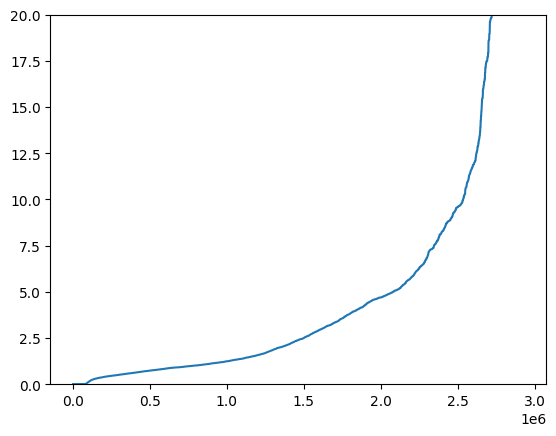

In [104]:
plt.plot(big_csv_gamma_filled_anomaly['PBR'].sort_values().values)
plt.ylim(0, 20)
plt.show()

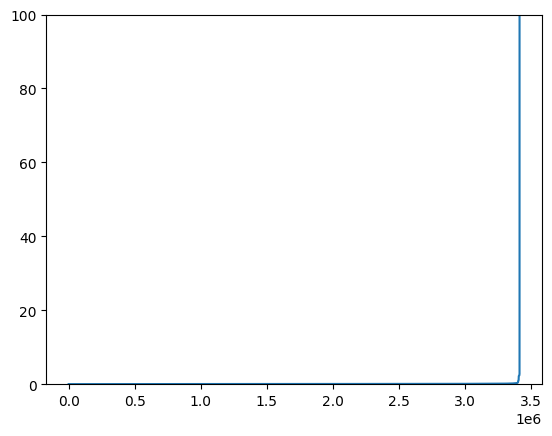

In [105]:
plt.plot(big_csv_gamma_filled_anomaly['volatility'].sort_values().values)
plt.ylim(0, 100)
plt.show()

暫定的に以下を規定する

- PER・PBRは上位0.5%を異常値とする
- PER・PBR・EV・ROE・PCFRは0未満の数字を異常値とする
- EPS・BPSは上位5%を異常値とする（要件等）
- ROEは上位0.05%を異常値とする
- ROAは上位0.01%を異常値とする
- PCFRは上位10%を異常値とする（要検討）

これらを　「銘柄ごとの内側線形補完」 -> 「市場平均埋め」 を実施する

In [106]:
big_csv_gamma_filled_anomaly['volatility'].describe()

count    3.414890e+06
mean     5.209724e-02
std      5.596343e-01
min      0.000000e+00
25%      2.345993e-02
50%      3.794882e-02
75%      5.708962e-02
max      2.464722e+02
Name: volatility, dtype: float64

In [107]:
def set_idx(cutting_of_pct: float) -> int:
    cutting_of_pct = cutting_of_pct# this parameter dosen't have truth
    length = len(big_csv_gamma_filled_anomaly.loc[big_csv_gamma_filled_anomaly['上場フラグ'] == 1, '上場フラグ'])
    idx = int(length*cutting_of_pct)
    return idx

In [108]:
anomaly_PER = big_csv_gamma_filled_anomaly.loc[big_csv_gamma_filled_anomaly['PER'].notna(), 'PER'].sort_values().tolist()[set_idx(0.995)]
anomaly_PBR = big_csv_gamma_filled_anomaly.loc[big_csv_gamma_filled_anomaly['PBR'].notna(), 'PBR'].sort_values().tolist()[set_idx(0.995)]
anomaly_EPS = big_csv_gamma_filled_anomaly.loc[big_csv_gamma_filled_anomaly['EPS'].notna(), 'EPS'].sort_values().tolist()[set_idx(0.95)]
anomaly_BPS = big_csv_gamma_filled_anomaly.loc[big_csv_gamma_filled_anomaly['BPS'].notna(), 'BPS'].sort_values().tolist()[set_idx(0.95)]
anomaly_ROE = big_csv_gamma_filled_anomaly.loc[big_csv_gamma_filled_anomaly['ROE'].notna(), 'ROE'].sort_values().tolist()[set_idx(0.9995)]
anomaly_ROA = big_csv_gamma_filled_anomaly.loc[big_csv_gamma_filled_anomaly['ROA'].notna(), 'ROA'].sort_values().tolist()[set_idx(0.9999)]
anomaly_CFPS = big_csv_gamma_filled_anomaly.loc[big_csv_gamma_filled_anomaly['CFPS'].notna(), 'CFPS'].sort_values().tolist()[set_idx(0.80)]
anomaly_PCFR = big_csv_gamma_filled_anomaly.loc[big_csv_gamma_filled_anomaly['PCFR'].notna(), 'PCFR'].sort_values().tolist()[set_idx(0.9)]
anomaly_volatility = 2
anomaly_beta = 2
anomaly_EV  = 0

In [109]:
for anomaly in [('PER', anomaly_PER), ('PBR', anomaly_PBR), ('EPS', anomaly_EPS), ('BPS', anomaly_BPS), ('ROE', anomaly_ROE), ('ROA', anomaly_ROA), ('CFPS', anomaly_CFPS), ('PCFR', anomaly_PCFR), ('EV', anomaly_EV), ('beta', anomaly_beta), ('volatility', anomaly_volatility)]:
    print(f'{anomaly[0]}: {anomaly[1]}')

PER: 3082.797250812628
PBR: 247.51515294298665
EPS: 3634.6977827383625
BPS: 56063.66318094737
ROE: 3.07396449704142
ROA: 0.7553688141923437
CFPS: 1034.5231216373218
PCFR: 90.03980483066724
EV: 0
beta: 2
volatility: 2


In [110]:
def mod_anomaly_values(group: pd.DataFrame, market_mean) -> pd.DataFrame:
    group.loc[group['PER']  > anomaly_PER,  'PER'] = np.nan
    group.loc[group['PBR']  > anomaly_PBR,  'PBR'] = np.nan
    group.loc[group['EPS']  > anomaly_EPS,  'EPS'] = np.nan
    group.loc[group['BPS']  > anomaly_BPS,  'BPS'] = np.nan
    group.loc[group['ROE']  > anomaly_ROE,  'ROE'] = np.nan
    group.loc[group['ROA']  > anomaly_ROA,  'ROA'] = np.nan
    group.loc[group['CFPS'] > anomaly_CFPS, 'CFPS'] = np.nan
    group.loc[group['PCFR'] > anomaly_PCFR, 'PCFR'] = np.nan
    group.loc[group['beta'] > anomaly_beta, 'beta'] = np.nan
    group.loc[group['volatility'] > anomaly_volatility, 'volatility'] = np.nan

    group.loc[group['EV']   < 0, 'EV'] = np.nan
    group.loc[group['PER']  < 0, 'PER'] = np.nan
    group.loc[group['PBR']  < 0, 'PBR'] = np.nan
    group.loc[group['PCFR'] < 0, 'PCFR'] = np.nan
    group.loc[group['ROE']  < 0, 'ROE'] = np.nan
    group.loc[group['上場フラグ'] == 1, 'open':] = group.loc[group['上場フラグ'] == 1, 'open':].interpolate(method='linear', limit_area='inside')
    group.loc[group['上場フラグ'] == 1, 'open':] = group.loc[group['上場フラグ'] == 1, 'open':].fillna(market_mean)
    
    return group

In [111]:
modified_big_csv_gamma = (
    big_csv_gamma_filled_anomaly
    .groupby('nikkei')
    .apply(mod_anomaly_values, market_mean=big_csv_gamma_filled_anomaly.loc[big_csv_gamma_filled_anomaly['上場フラグ'] == 1, 'open':].mean())
    .reset_index(drop=True)
)

C:\Users\Ito Yuki\AppData\Local\Temp\ipykernel_26976\880811772.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(mod_anomaly_values, market_mean=big_csv_gamma_filled_anomaly.loc[big_csv_gamma_filled_anomaly['上場フラグ'] == 1, 'open':].mean())


In [112]:
modified_big_csv_gamma.loc[modified_big_csv_gamma['上場フラグ'] == 1, 'beta'].describe()

count    2.930495e+06
mean     6.170951e-01
std      7.657509e-01
min     -9.459266e+01
25%      1.653502e-01
50%      5.817137e-01
75%      1.050034e+00
max      2.000000e+00
Name: beta, dtype: float64

In [113]:
modified_big_csv_gamma.count().sort_values(ascending=True)

close          2930495
weekly_low     2930495
weekly_high    2930495
open           2930495
slowd          2930495
                ...   
volatility     3425645
Unnamed: 0     5248023
上場フラグ          5248023
week_id        5248023
nikkei         5248023
Length: 67, dtype: int64

#### 最終調整

In [114]:
# allin_csv_v1 = modified_big_csv_gamma.drop(columns=['Unnamed: 0', 'anomaly', 'anomaly_score'])
allin_csv_v1 = modified_big_csv_gamma.drop(columns=['Unnamed: 0'])

In [115]:
allin_csv_v1

,nikkei,week_id,上場フラグ,open,weekly_high,weekly_low,close,return,10mom,slowk,...,株主資本回転率,PER,PBR,EV,EPS,BPS,CFPS,PCFR,beta,volatility
0,N0000001,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,N0000001,1,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,N0000001,2,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,N0000001,3,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,N0000001,4,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5248018,N0091607,1194,1,1472.0,1472.0,1472.0,1472.0,-0.008754,0.008910,70.521542,...,0.858607,44.256554,4.665824,1.420570e+11,108.967828,2950.221225,232.507534,42.356285,-0.036330,0.015026
5248019,N0091607,1195,1,1490.0,1505.0,1490.0,1500.0,0.019022,0.018330,70.256992,...,0.855676,40.921281,4.565057,1.420741e+11,118.042436,2956.164674,246.102153,41.528933,-0.069015,0.014565
5248020,N0091607,1196,1,1522.0,1525.0,1499.0,1507.0,0.004667,0.033608,67.494908,...,1.077614,33.431197,5.699286,1.427184e+11,137.880596,2927.911994,250.235789,43.200735,-0.067893,0.014556
5248021,N0091607,1197,1,1488.0,1488.0,1488.0,1488.0,-0.012608,0.012934,63.022748,...,1.143725,50.490728,6.145609,1.417289e+11,171.437972,3169.686317,310.507952,47.771931,-0.070607,0.013118


In [116]:
allin_csv_v1['nikkei'].nunique()

4377

In [117]:
del_nikkei = [
	"N0000214",
	"N0000280",
	"N0000427",
	"N0000440",
	"N0000666",
	"N0000724",
	"N0000992",
	"N0001085",
	"N0001200",
	"N0001245",
	"N0001413",
	"N0001814",
	"N0002528",
	"N0007657",
	"N0009436",
	"N0009613",
	"N0011066",
	"N0012040",
	"N0016094",
	"N0019904",
	"N0020222",
	"N0021062",
	"N0023982",
	"N0024143",
	"N0030100",
	"N0030217",
	"N0030344",
	"N0030359",
	"N0030396",
	"N0030587",
	"N0030983",
	"N0031235",
	"N0031573",
	"N0031621",
	"N0031661",
	"N0031687",
	"N0031761",
	"N0031826",
	"N0031841",
	"N0031910",
	"N0031933",
	"N0031977",
	"N0032005",
	"N0032055",
	"N0032063",
	"N0032149",
	"N0032223",
	"N0032254",
	"N0032283",
	"N0032292",
	"N0032293",
	"N0032345",
	"N0032346",
	"N0032347",
	"N0032382",
	"N0032397",
	"N0032452",
	"N0032465",
	"N0032471",
	"N0032491",
	"N0032497",
	"N0032505",
	"N0032510",
	"N0032518",
	"N0032524",
	"N0032535",
	"N0032551",
	"N0032578",
	"N0032581",
	"N0032582",
	"N0032584",
	"N0032616",
	"N0032617",
	"N0032622",
	"N0032639",
	"N0032674",
	"N0032676",
	"N0032705",
	"N0032714",
	"N0032715",
	"N0032730",
	"N0032744",
	"N0032746",
	"N0032783",
	"N0032784",
	"N0032791",
	"N0032800",
	"N0032801",
	"N0032803",
	"N0032808",
	"N0032813",
	"N0032818",
	"N0032821",
	"N0032822",
	"N0032835",
	"N0032845",
	"N0032854",
	"N0032859",
	"N0032861",
	"N0032863",
	"N0032877",
	"N0032882",
	"N0032904",
	"N0032905",
	"N0032907",
	"N0032908",
	"N0032909",
	"N0032911",
	"N0032912",
	"N0032913",
	"N0032915",
	"N0032917",
	"N0032918",
	"N0032919",
	"N0032920",
	"N0032921",
	"N0032922",
	"N0032923",
	"N0032924",
	"N0032925",
	"N0032927",
	"N0032929",
	"N0032930",
	"N0032932",
	"N0032934",
	"N0032935",
	"N0032936",
	"N0032937",
	"N0032940",
	"N0032941",
	"N0032942",
	"N0032943",
	"N0032946",
	"N0032947",
	"N0032948",
	"N0032951",
	"N0032952",
	"N0032953",
	"N0032954",
	"N0032955",
	"N0032958",
	"N0032959",
	"N0032960",
	"N0032961",
	"N0032963",
	"N0032965",
	"N0032966",
	"N0032967",
	"N0032968",
	"N0032969",
	"N0032972",
	"N0032974",
	"N0032975",
	"N0032976",
	"N0032977",
	"N0032978",
	"N0032979",
	"N0032980",
	"N0032981",
	"N0032982",
	"N0032984",
	"N0032985",
	"N0032986",
	"N0032988",
	"N0032989",
	"N0032990",
	"N0032991",
	"N0032992",
	"N0032993",
	"N0032995",
	"N0032996",
	"N0032997",
	"N0032998",
	"N0032999",
	"N0033001",
	"N0033002",
	"N0033003",
	"N0033005",
	"N0033006",
	"N0033007",
	"N0033008",
	"N0033009",
	"N0033010",
	"N0033011",
	"N0033012",
	"N0033013",
	"N0033014",
	"N0033015",
	"N0033017",
	"N0033018",
	"N0033019",
	"N0033020",
	"N0033021",
	"N0033022",
	"N0033023",
	"N0033024",
	"N0033025",
	"N0033026",
	"N0033027",
	"N0033028",
	"N0033030",
	"N0035150",
	"N0038827",
	"N0038831",
	"N0039193",
	"N0039513",
	"N0040294",
	"N0040523",
	"N0040679",
	"N0041658",
	"N0041834",
	"N0041835",
	"N0041846",
	"N0041892",
	"N0044002",
	"N0044745",
	"N0044974",
	"N0045010",
	"N0045111",
	"N0045326",
	"N0045784",
	"N0050825",
	"N0051847",
	"N0052517",
	"N0053828",
	"N0055003",
	"N0055055",
	"N0055164",
	"N0055588",
	"N0055938",
	"N0056747",
]

In [118]:
allin_csv_v1.to_csv('weekly_All_v1.csv', index=False)